# 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
# Set number of cores
N_CORES = 60

In [ ]:
# Load the CSV file
df = pd.read_csv('/home/FFM16S_train_data.csv', index_col='seq_ID')
df

,Atopobiaceae,Streptococcaceae,Actinomycetaceae,Lachnospiraceae,Anaerovoracaceae,Gemellaceae,Veillonellaceae,Bifidobacteriaceae,Synergistaceae,Propionibacteriaceae,...,Pseudomonadaceae,Fusobacteriaceae,Saccharimonadaceae,Bacillaceae,Leptotrichiaceae,Hungateiclostridiaceae,Ethanoligenenaceae,Selenomonadaceae,Flavobacteriaceae,Factor9
seq_ID,,,,,,,,,,,,,,,,,,,,,
02_seqx1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,-3.487101,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.364441
04_seqx1,-3.167506,-0.717938,-3.167506,4.264238,-0.334292,0.000000,0.650207,1.663471,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,-3.860653,0.000000,0.0,2.038256
07_seqx1,-4.041172,0.719576,0.000000,3.216418,0.000000,-4.446637,2.601532,0.861631,0.0,0.000000,...,0.000000,0.0,-2.837199,0.0,0.0,0.0,0.000000,0.000000,0.0,0.433865
09_seqx1,-3.174947,2.873213,-0.218880,2.308004,-0.354891,-2.974276,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.327578
11_seqx1,-0.620479,-0.864676,-3.328529,3.915699,-2.149874,0.000000,2.992015,2.665744,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,-2.463531,1.539006,0.0,-2.570986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90_seq12,-2.891508,3.444786,0.809794,4.637630,-4.500946,-2.796198,-2.709187,1.071208,0.0,-0.357811,...,0.000000,0.0,-1.975217,0.0,0.0,0.0,0.000000,0.000000,0.0,0.760045
91_seq12,-4.049521,-0.508562,0.000000,4.459287,-0.137498,-3.489905,-2.257762,0.000000,0.0,0.000000,...,0.000000,0.0,-3.644056,0.0,0.0,0.0,0.000000,0.000000,0.0,0.484095
92_seq12,-4.659317,0.550169,-1.401221,4.958087,0.000000,-3.049879,0.000000,2.179624,0.0,0.000000,...,0.000000,0.0,-3.273023,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.174335


In [4]:
# Separate features (X) and target (y)
y = df['Factor9']  # The stratification variable
X = df.drop('Factor9', axis=1)  # All columns except 'status'

In [ ]:
# Step 2: Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.33, 
    random_state=42,
)

In [6]:
#Lets also remove missing values 

# Calculate missing percentage for each feature
missing_percent = (X_train.isna().sum() / len(X_train)) * 100

# Display features with high missing rates
print(f"Features with >30% missing values: {(missing_percent > 50).sum()}")
print(f"Features with <=30% missing values: {(missing_percent <= 50).sum()}")

Features with >30% missing values: 0
Features with <=30% missing values: 58


In [ ]:
# Filter features with <=30% missing values
features_to_keep = missing_percent[missing_percent <= 50].index.tolist()

# Apply to train and test sets
X_train_selected = X_train[features_to_keep]
X_test_selected = X_test[features_to_keep]

In [ ]:
# Load the mskcc dataset
# Load the CSV file
msk = pd.read_csv('/home/MSKCC16S_val_data.csv', index_col='seq_ID')
msk

,Atopobiaceae,Streptococcaceae,Actinomycetaceae,Lachnospiraceae,Anaerovoracaceae,Gemellaceae,Veillonellaceae,Bifidobacteriaceae,Synergistaceae,Propionibacteriaceae,...,Muribaculaceae,Pseudomonadaceae,Fusobacteriaceae,Saccharimonadaceae,Bacillaceae,Leptotrichiaceae,Hungateiclostridiaceae,Ethanoligenenaceae,Selenomonadaceae,Flavobacteriaceae
seq_ID,,,,,,,,,,,,,,,,,,,,,
1011A,1.761466,4.060880,2.746573,4.388960,0.772689,-0.264047,-0.001683,-0.880234,-1.403482,-1.778175,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1013A,0.000000,1.678376,-0.072561,5.600418,-0.092764,-1.681999,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1014A,0.000000,0.202666,-1.963787,4.160499,-0.410438,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1014B,-1.775529,2.648965,1.576437,2.518951,0.000000,-1.638328,0.000000,-3.355980,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1014C,-1.503535,3.279021,2.228709,3.778977,0.000000,-0.983659,-2.196682,-3.495965,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994A,0.000000,2.131994,-0.635097,4.311795,-2.598706,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998A,0.000000,0.671782,-1.087402,3.132106,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FMT.0213B,-1.279197,3.126584,-0.347639,5.100926,-1.541561,-1.279197,0.000000,-1.136096,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Define same sample weights to emphasize the tails of the distribution
weights_full = 1 + np.abs(y_train)

Pipeline: StandardScaler -> ElasticNet: (ElasticNet is scale-sensitive; wrapping in a Pipeline means the scaler is refit on the training fold only, inside each CV split, which avoids leakage from validation folds.

In [10]:
en_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('enet', ElasticNet(
        random_state=42,
        max_iter=20000,   # coordinate descent needs more iters than the default 1000
                           # for small alphas / correlated features - bump if you see
                           # ConvergenceWarning
        selection='cyclic'
    ))
])

In [ ]:
# Define the grid 
param_grid = {
    'enet__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'enet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
}

In [14]:
# Run the grid search 
grid_search = GridSearchCV(
    estimator=en_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=60,
    return_train_score=True
)
 
# sample_weight for a Pipeline must be passed with the step-name prefix
grid_search.fit(
    X_train_selected, y_train,
    enet__sample_weight=weights_full
)
 
print("Best params:", grid_search.best_params_)
print("Best CV score (neg MSE):", grid_search.best_score_)

Best params: {'enet__alpha': 0.05, 'enet__l1_ratio': 0.1}
Best CV score (neg MSE): -0.050341776078519404


In [15]:
# Get the final model 
X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X_train_selected, y_train, weights_full,
    test_size=0.15, random_state=42
)
 
final_model = grid_search.best_estimator_  # already refit on full X_train_selected/y_train
 
val_pred = final_model.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred, sample_weight=w_val))
print(f"\nHeld-out val RMSE (diagnostic only): {val_rmse:.4f}")


Held-out val RMSE (diagnostic only): 0.1827


In [16]:
# Evaluate on the test set
y_pred = final_model.predict(X_test_selected)
 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
 
print(f"\nTest Set Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


Test Set Performance:
RMSE: 0.2203
MAE: 0.1260
R²: 0.8972


In [17]:
residuals = y_test - y_pred

tail_mask_high = y_test > y_test.quantile(0.9)
tail_mask_low = y_test < y_test.quantile(0.1)
print("Mean residual top 10%:", residuals[tail_mask_high].mean())
print("Mean residual bottom 10%:", residuals[tail_mask_low].mean())

train_pred = final_model.predict(X_tr)
print("Train RMSE:", np.sqrt(np.mean((y_tr - train_pred)**2)))
print("Test RMSE:", np.sqrt(np.mean((y_test - y_pred)**2)))

Mean residual top 10%: 0.10823161162349275
Mean residual bottom 10%: 0.06946423278049216
Train RMSE: 0.18417286864327648
Test RMSE: 0.22026114563303206


In [19]:
# Re-predict the mskcc cohort
y_msk = final_model.predict(msk)

In [20]:
result_df = pd.DataFrame({
    'predicted_f9': y_msk
}, index=msk.index)

result_df

,predicted_f9
seq_ID,
1011A,-0.191816
1013A,0.359779
1014A,0.469232
1014B,-0.192850
1014C,-0.115994
...,...
994A,-0.259706
998A,-0.043930
FMT.0213B,-0.002482


6 / 58 features had coefficient shrunk to exactly 0


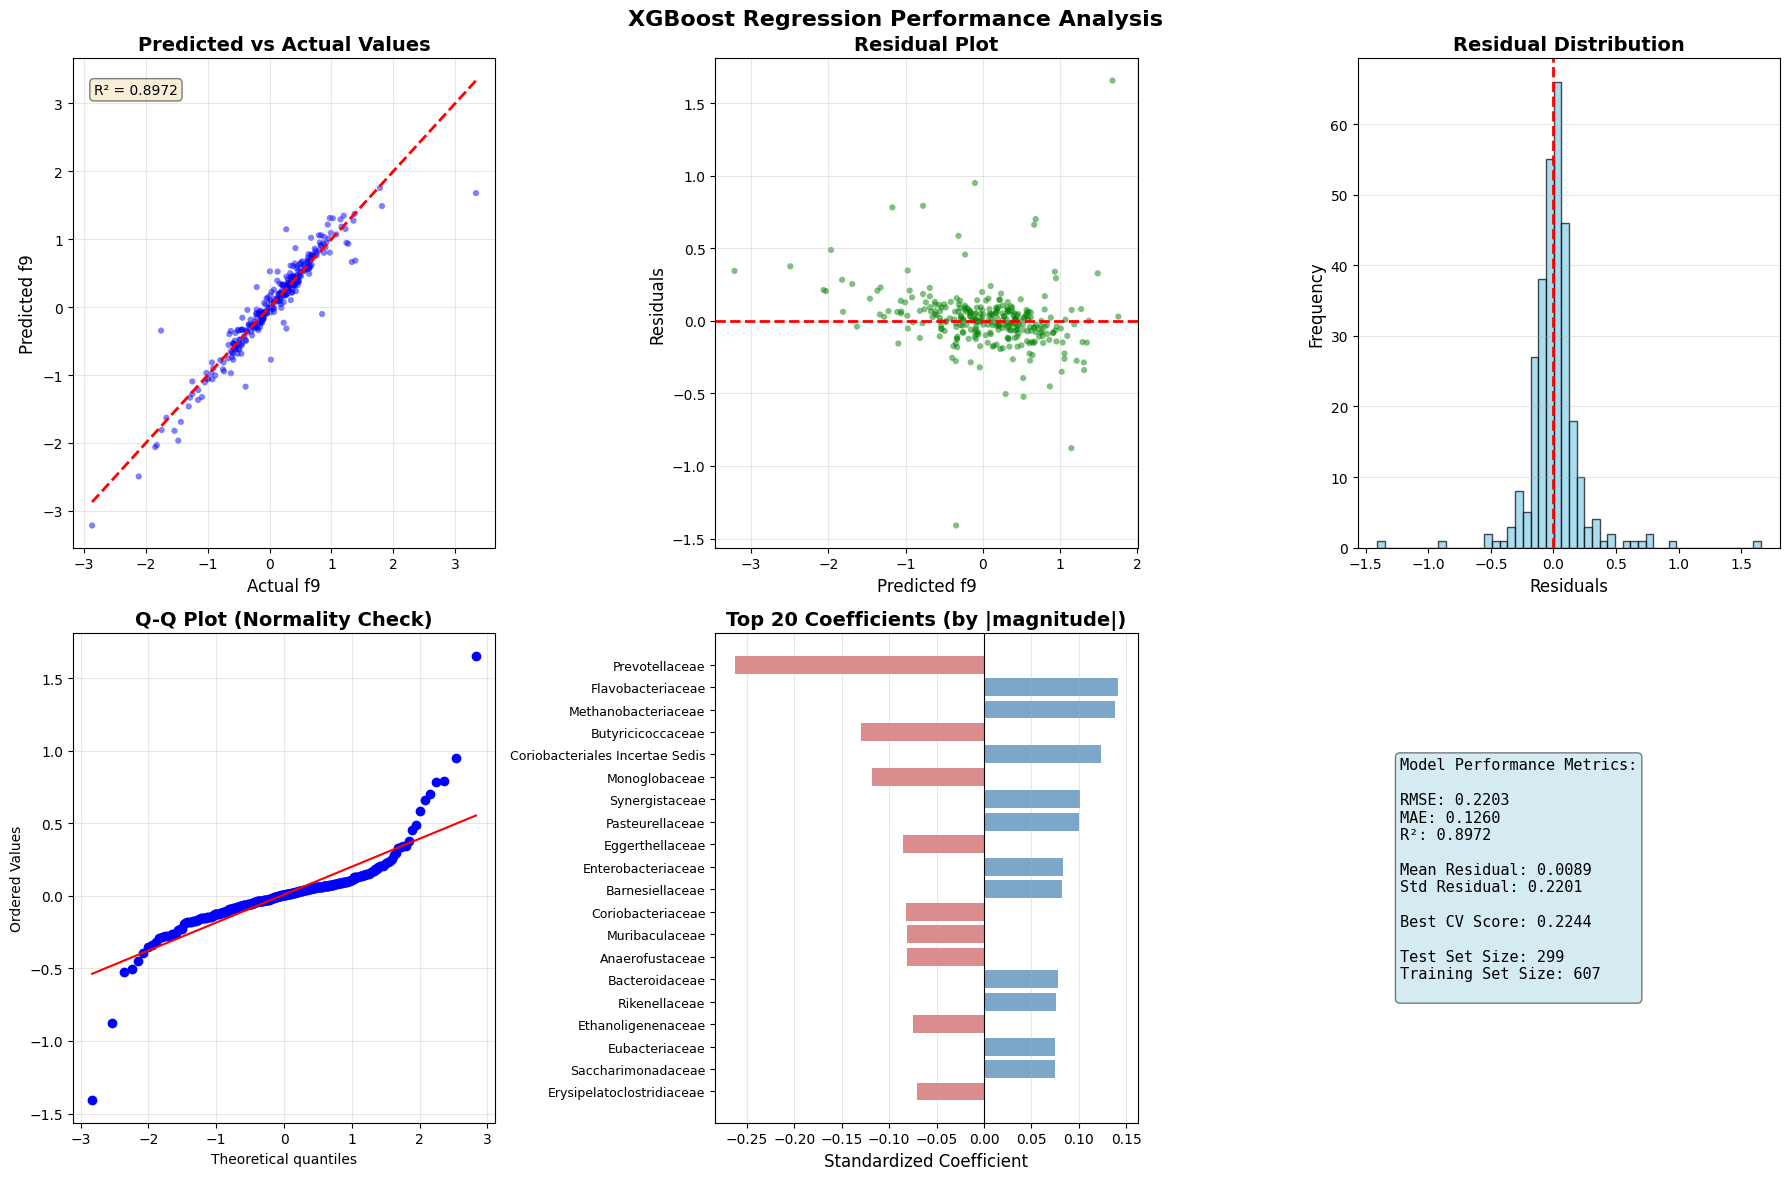


Performance Summary:
RMSE: 0.2203
MAE: 0.1260
R²: 0.8972


In [ ]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
residuals = y_test - y_pred

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Elastic Net Regression Performance Analysis', fontsize=16, fontweight='bold')

# 1. Predicted vs Actual
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=20, c='blue', edgecolors='none')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual f9', fontsize=12)
axes[0, 0].set_ylabel('Predicted f9', fontsize=12)
axes[0, 0].set_title('Predicted vs Actual Values', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[0, 0].transAxes, 
                verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, s=20, c='green', edgecolors='none')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted f9', fontsize=12)
axes[0, 1].set_ylabel('Residuals', fontsize=12)
axes[0, 1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of Residuals
axes[0, 2].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 2].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 2].set_xlabel('Residuals', fontsize=12)
axes[0, 2].set_ylabel('Frequency', fontsize=12)
axes[0, 2].set_title('Residual Distribution', fontsize=14, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Feature Importance (Top 20)
enet = final_model.named_steps['enet']
scaler = final_model.named_steps['scaler']

# Use standardized-scale coefficients for cross-feature comparability
coefs = enet.coef_

if isinstance(X_train_selected, pd.DataFrame):
    feature_names = X_train_selected.columns.tolist()
elif hasattr(selector, 'get_support'):
    original_features = X_train.columns if isinstance(X_train, pd.DataFrame) else [f'Feature_{i}' for i in range(X_train.shape[1])]
    feature_names = [original_features[i] for i in np.where(selector.get_support())[0]]
else:
    feature_names = [f'Feature_{i}' for i in range(X_train_selected.shape[1])]

importance_data = list(zip(feature_names, coefs))
# rank by magnitude, but keep the signed value for display/coloring
importance_data.sort(key=lambda x: abs(x[1]), reverse=True)
top_20 = importance_data[:20]

names = [x[0] for x in top_20]
values = [x[1] for x in top_20]
colors = ['steelblue' if v >= 0 else 'indianred' for v in values]

y_pos = np.arange(len(names))
axes[1, 1].barh(y_pos, values, color=colors, alpha=0.7)
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(names, fontsize=9)
axes[1, 1].invert_yaxis()
axes[1, 1].axvline(0, color='black', linewidth=0.8)
axes[1, 1].set_xlabel('Standardized Coefficient', fontsize=12)
axes[1, 1].set_title('Top 20 Coefficients (by |magnitude|)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

n_zero = np.sum(coefs == 0)
print(f"{n_zero} / {len(coefs)} features had coefficient shrunk to exactly 0")

# 5. Error Metrics Summary
metrics_text = f"""Model Performance Metrics:

RMSE: {rmse:.4f}
MAE: {mae:.4f}
R²: {r2:.4f}

Mean Residual: {np.mean(residuals):.4f}
Std Residual: {np.std(residuals):.4f}

Best CV Score: {np.sqrt(-grid_search.best_score_):.4f}

Test Set Size: {len(y_test)}
Training Set Size: {len(y_train)}
"""
axes[1, 2].text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
                family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1, 2].axis('off')

print(f"\n{'='*50}")
print(f"Performance Summary:")
print(f"{'='*50}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"{'='*50}")

In [ ]:
#export the results 
result_df.to_csv('/home/MSKCC16S_LF9score_predictions.csv', index=True)